##Exercice **1**

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Définition des données


In [2]:
# Données du problème
X = np.array([4775, 1350, 5680, 5872, 7964, 3072, 1942, 8802])  # PIB par habitant
Y = np.array([63, 45, 62, 69, 81, 56, 50, 83])  # Taux de scolarisation

### Calcul des statistiques


In [3]:
# Moyennes
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Variances
X_var = np.var(X, ddof=0)  # Variance de X
Y_var = np.var(Y, ddof=0)  # Variance de Y

# Affichage des résultats
print(f"PIB moyen: {X_mean:.2f} dollars")
print(f"Taux de scolarisation moyen: {Y_mean:.2f}%")
print(f"Variance du PIB: {X_var:.2f}")
print(f"Variance du taux de scolarisation: {Y_var:.2f}")

PIB moyen: 4932.12 dollars
Taux de scolarisation moyen: 63.62%
Variance du PIB: 6358512.61
Variance du taux de scolarisation: 162.48


### Estimation des coefficients de régression


In [4]:
# Calcul de la covariance
cov_XY = np.mean((X - X_mean) * (Y - Y_mean))

# Calcul des coefficients de régression
beta_1 = cov_XY / X_var
beta_0 = Y_mean - beta_1 * X_mean

# Affichage des coefficients
print(f"Coefficient β0 (intercept): {beta_0:.2f}")
print(f"Coefficient β1 (pente): {beta_1:.5f}")

Coefficient β0 (intercept): 39.07
Coefficient β1 (pente): 0.00498


### Modèle de régression


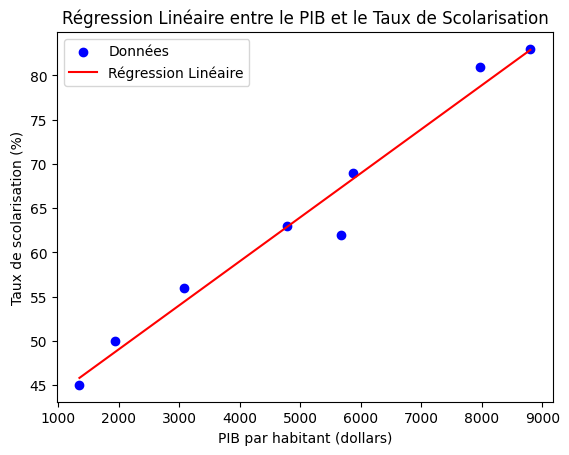

In [5]:
# Tracé des points de données
plt.scatter(X, Y, color='blue', label='Données')

# Tracé de la droite de régression
X_line = np.linspace(min(X), max(X), 100)
Y_line = beta_0 + beta_1 * X_line
plt.plot(X_line, Y_line, color='red', label='Régression Linéaire')

# Configuration du graphique
plt.xlabel("PIB par habitant (dollars)")
plt.ylabel("Taux de scolarisation (%)")
plt.title("Régression Linéaire entre le PIB et le Taux de Scolarisation")
plt.legend()
plt.show()

L'équation estimée du modèle est :
\[ Y = β0 + β1 \times X \]
Avec :
- β0 = **39.07**
- β1 = **0.00498**

Cela signifie qu'une augmentation de **1000 dollars** du PIB correspond en moyenne à une augmentation de **4.98 points** du taux de scolarisation.

## Exercice **2**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [7]:
# Données
X = np.array([2, 3, 5, 7, 9, 10, 4, 6, 8, 1]).reshape(-1, 1)
Y = np.array([10, 12, 15, 18, 19, 20, 13, 16, 18, 8]).reshape(-1, 1)

In [8]:
# Fonction pour estimer les paramètres avec la méthode des moindres carrés
def moindres_carres(X, Y):
    X_b = np.hstack((np.ones((len(X), 1)), X))  # Ajout d'une colonne de 1 pour β0
    Beta_estime = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ Y  # Pseudo-inverse pour plus de stabilité
    return Beta_estime


In [9]:
# Estimation des paramètres
beta_estime = moindres_carres(X, Y)
beta_0, beta_1 = beta_estime.flatten()

print(f"β0 estimé: {beta_0:.2f}")
print(f"β1 estimé: {beta_1:.2f}")


β0 estimé: 7.67
β1 estimé: 1.32


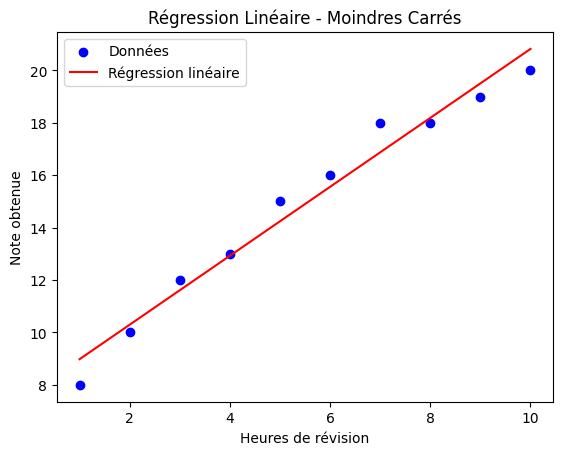

In [10]:
# Tracé des points et de la droite de régression
plt.scatter(X, Y, color='blue', label='Données')
X_range = np.linspace(min(X), max(X), 100).reshape(-1, 1)
Y_pred = beta_0 + beta_1 * X_range
plt.plot(X_range, Y_pred, color='red', label='Régression linéaire')
plt.xlabel('Heures de révision')
plt.ylabel('Note obtenue')
plt.legend()
plt.title('Régression Linéaire - Moindres Carrés')
plt.show()